In [2]:
# Read the names
words = open('../data/names.txt', 'r').read().splitlines()
print(f"Number of words: {len(words)}")
print(f"First 10: {words[:10]}")

Number of words: 6466
First 10: ['aabid', 'aabida', 'aachal', 'aadesh', 'aadil', 'aadish', 'aaditya', 'aaenab', 'aafreen', 'aafrin']


In [3]:
# Use '.' as the special start/end token (single character)
b = {}
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1

sorted(b.items(), key=lambda kv: -kv[1])[:10]

[(('a', '.'), 1552),
 (('a', 'n'), 1401),
 (('s', 'h'), 1233),
 (('.', 's'), 1217),
 (('h', 'a'), 1169),
 (('r', 'a'), 1011),
 (('a', 'r'), 932),
 (('i', '.'), 919),
 (('n', 'a'), 711),
 (('a', 'm'), 658)]

In [4]:
sorted(b.items(), key = lambda kv: -kv[1])

[(('a', '.'), 1552),
 (('a', 'n'), 1401),
 (('s', 'h'), 1233),
 (('.', 's'), 1217),
 (('h', 'a'), 1169),
 (('r', 'a'), 1011),
 (('a', 'r'), 932),
 (('i', '.'), 919),
 (('n', 'a'), 711),
 (('a', 'm'), 658),
 (('m', 'a'), 629),
 (('n', '.'), 626),
 (('s', 'a'), 602),
 (('.', 'a'), 586),
 (('r', '.'), 574),
 (('a', 'l'), 549),
 (('.', 'm'), 549),
 (('.', 'r'), 548),
 (('e', 'e'), 502),
 (('i', 'n'), 478),
 (('h', 'i'), 421),
 (('h', '.'), 406),
 (('a', 's'), 403),
 (('n', 'd'), 402),
 (('k', 'a'), 400),
 (('.', 'b'), 398),
 (('r', 'i'), 395),
 (('l', '.'), 394),
 (('t', 'a'), 387),
 (('l', 'a'), 383),
 (('a', 't'), 382),
 (('.', 'k'), 378),
 (('.', 'p'), 377),
 (('y', 'a'), 371),
 (('.', 'n'), 360),
 (('m', '.'), 345),
 (('j', 'a'), 343),
 (('n', 'i'), 324),
 (('e', 'n'), 318),
 (('p', 'a'), 316),
 (('d', 'e'), 312),
 (('e', 'r'), 306),
 (('t', '.'), 301),
 (('.', 'j'), 297),
 (('.', 'd'), 296),
 (('a', 'j'), 289),
 (('u', '.'), 287),
 (('i', 's'), 285),
 (('t', 'i'), 279),
 (('i', 'r'), 

In [5]:
import torch

In [6]:
# Vocab now includes '.' as index 0
chars = ['.'] + sorted(list(set(''.join(words))))
stoi = {s:i for i, s in enumerate(chars)}
itos = {i:s for s, i in stoi.items()}

print(f"Vocab size: {len(chars)}")
print(stoi)

Vocab size: 27
{'.': 0, 'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26}


In [7]:
# Build the count matrix
N = torch.zeros((len(chars), len(chars)), dtype=torch.int32)

for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1

(np.float64(-0.5), np.float64(26.5), np.float64(26.5), np.float64(-0.5))

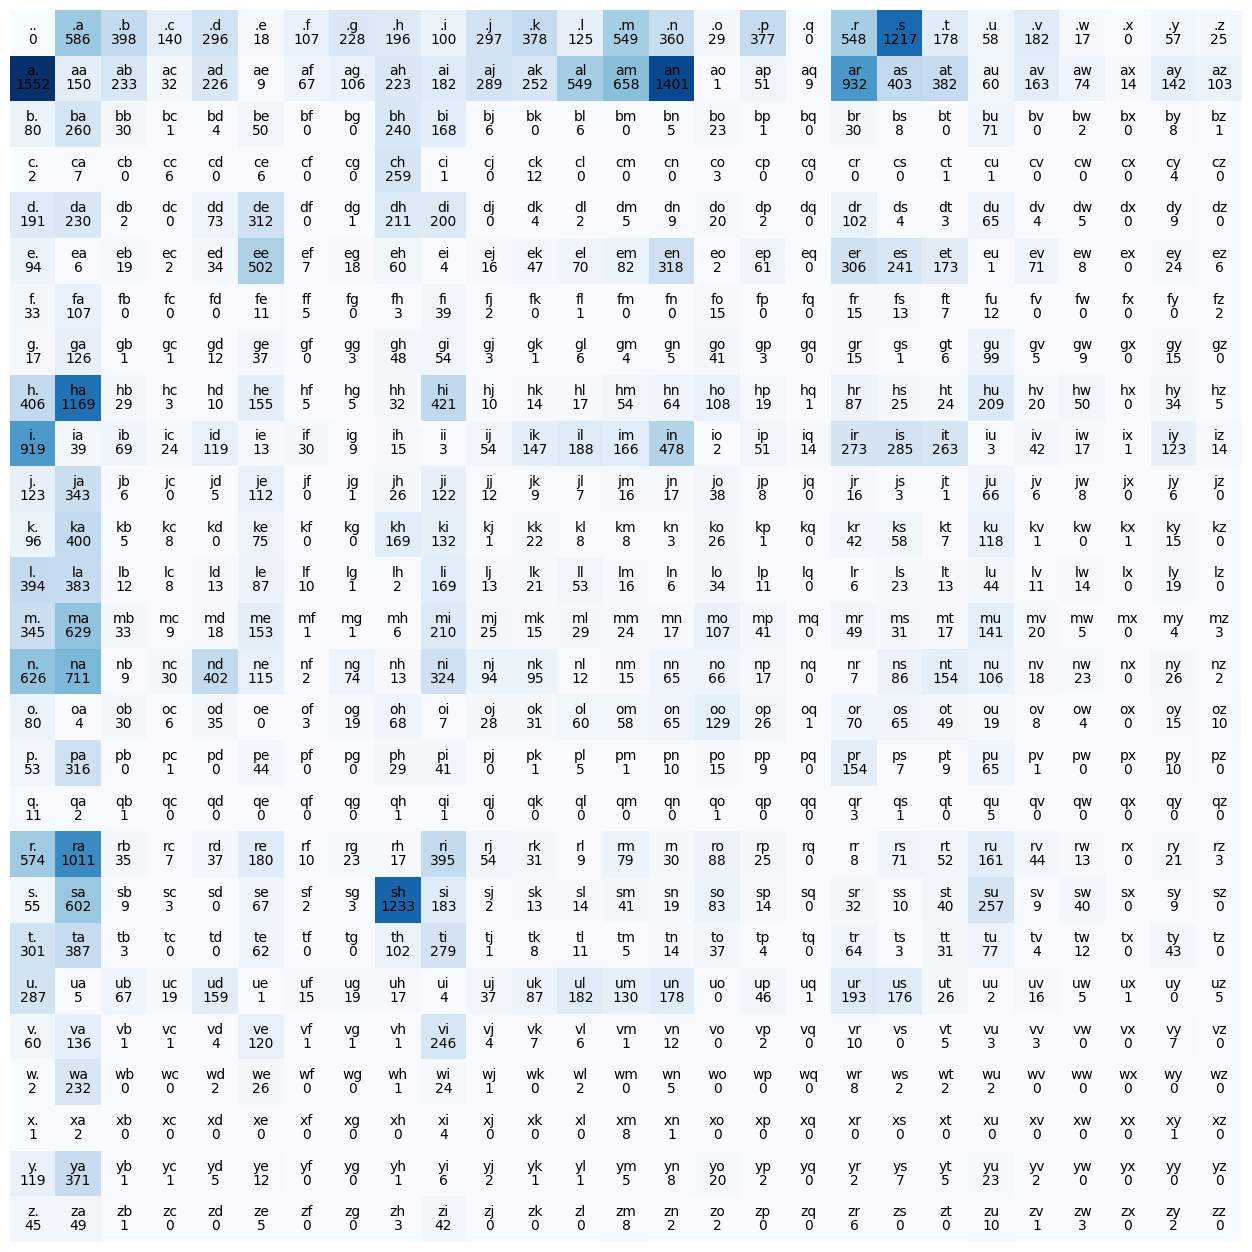

In [8]:
#A visual representation of how many of each bigrams are there, the darker the blue the more the number of the bigrams
import matplotlib.pyplot as plt
%matplotlib inline
plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='black')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color='black')
plt.axis('off')

In [ ]:
P=(N+1).float()
#keepdims true required for normalisation read in pytorch documentation
P/=P.sum(1, keepdims=True)

In [ ]:
#This block of code generates 10 samples that the neural net has "learnt" from the samples.
#Outputs arent very good/legible because a bigram model is not good at making names
for i in range(10):
    out=[]
    ix=0
    while True:
        p=P[ix]
        ix=torch.multinomial(p,num_samples=1,replacement=True,generator=g).item()
        if ix==0:
            break
        out.append(itos[ix])
    print(''.join(out))

arohari
lahimijiloohi
paraletisaniti
bai
bhija
aisha
b
khamindiyana
apamarinnukadz
k
